# 03 - Data Imbalance Analysis
Analyze identity-frequency imbalance in the training data and prepare diagnostics for imbalance-focused training experiments.


In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

project_root = Path("..").resolve()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import src.data as data
from src.utils import get_device, set_seed

RANDOM_SEED = 42
set_seed(RANDOM_SEED)

plt.style.use("default")

import src.feature_cache as feature_cache
from src.models import MetricLearningModel, build_backbone

device = get_device()
device

In [ ]:
config = {
    "data_dir": Path("../data"),
    "checkpoint_path": Path("../checkpoints/e3_data_imbalance"),
    "embeddings_cache_dir": Path("../checkpoints/embedding_cache"),
    "val_split": 0.2,
    "backbone_name": "eva02_large_patch14_448.mim_m38m_ft_in22k_in1k",
    "input_size": 448,
    "embedding_dim": 256,
    "hidden_dim": 512,
    "dropout": 0.3,
    "arcface_margin": 0.5,
    "arcface_scale": 64.0,
    "batch_size": 32,
    "num_workers": 2,
    "seed": RANDOM_SEED,
}

## Imbalance Statistics and Visualizations

In [27]:
# load train data
train_df = data.load_train_df(config["data_dir"])

identity_counts = train_df["ground_truth"].value_counts().sort_values(ascending=False)

print(
    f"Number of identities:            {identity_counts.shape[0]}"
    f"\nTotal number of images:          {identity_counts.sum()}"
    f"\nMinimum images:                  {identity_counts.min()}"
    f"\nMaximum images:                  {identity_counts.max()}"
    f"\nMean images:                     {identity_counts.mean():.2f}"
    f"\nMedian images:                   {identity_counts.median()}"
    f"\nStandard deviation of images:    {identity_counts.std():.2f}"
    f"\nInterquartile range of images:   {(identity_counts.quantile(0.75) - identity_counts.quantile(0.25)):.2f}"
    f"\nMin-Max ratio of images:         {(identity_counts.max() / identity_counts.min()):.2f}"
)

Number of identities:            31
Total number of images:          1895
Minimum images:                  13
Maximum images:                  183
Mean images:                     61.13
Median images:                   45.0
Standard deviation of images:    50.46
Interquartile range of images:   65.50
Min-Max ratio of images:         14.08


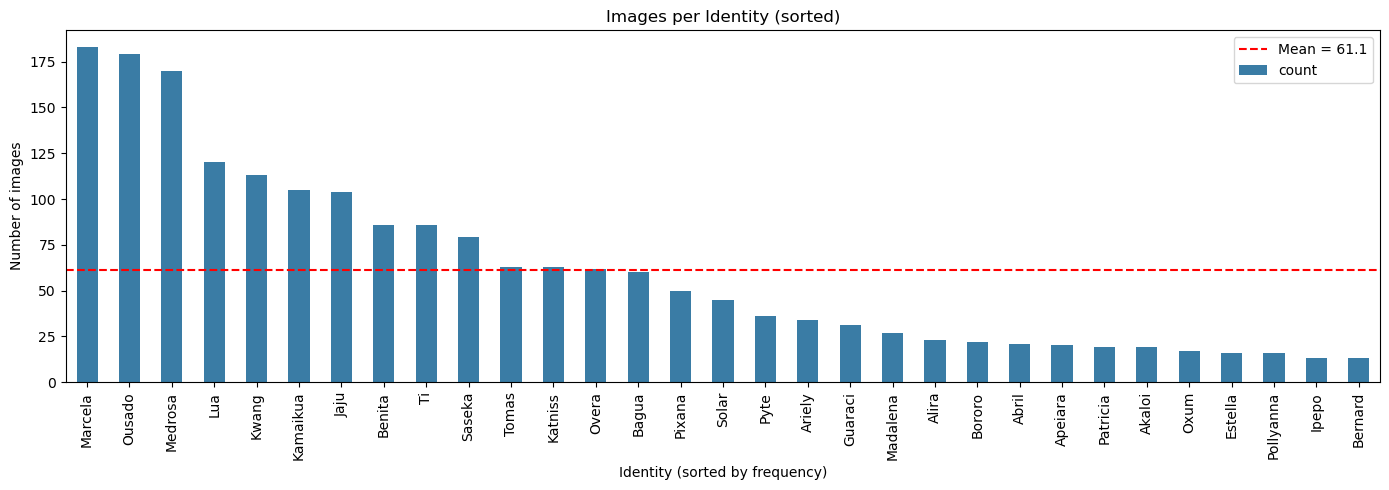

In [5]:
fig, ax = plt.subplots(figsize=(14, 5))
identity_counts.plot(kind="bar", ax=ax, color="#3A7CA5")
ax.set_title("Images per Identity (sorted)")
ax.set_xlabel("Identity (sorted by frequency)")
ax.set_ylabel("Number of images")
ax.axhline(identity_counts.mean(), color="red", linestyle="--", linewidth=1.5, label=f"Mean = {identity_counts.mean():.1f}")
ax.legend()
plt.tight_layout()
plt.show()


## Load ArcFace Checkpoint and Embeddings


In [ ]:
train_df_encoded, label_encoder = data.encode_labels(train_df)
train_data, val_data = data.train_val_split(
    train_df_encoded,
    val_split=config["val_split"],
    seed=config["seed"],
    stratify_col="ground_truth",
)

num_classes = len(label_encoder.classes_)

backbone = build_backbone(config["backbone_name"], pretrained=True).to(device)
backbone.eval()
backbone_out_dim = getattr(backbone, "num_features", None)
if backbone_out_dim is None:
    raise ValueError("Backbone output dimension not found")

backbone_train_loader, backbone_val_loader = data.create_backbone_dataloaders(
    backbone,
    train_data,
    val_data,
    img_dir=config["data_dir"] / "train" / "train",
    input_size=config["input_size"],
    batch_size=config["batch_size"],
    num_workers=config["num_workers"],
)

cache_dir = config["embeddings_cache_dir"]
cache_dir.mkdir(exist_ok=True)
cache_key = f"{config['backbone_name'].replace(':', '_').replace('/', '_')}_{config['input_size']}"

train_cache = cache_dir / f"train_{cache_key}.npz"
val_cache = cache_dir / f"val_{cache_key}.npz"

train_embeddings, train_labels = feature_cache.get_or_create_embeddings(
    train_cache,
    backbone,
    backbone_train_loader,
    device,
)
val_embeddings, val_labels = feature_cache.get_or_create_embeddings(
    val_cache,
    backbone,
    backbone_val_loader,
    device,
)

print(f"Train embeddings: {train_embeddings.shape}")
print(f"Val embeddings: {val_embeddings.shape}")

In [ ]:
head_model = MetricLearningModel(
    input_dim=backbone_out_dim,
    num_classes=num_classes,
    embedding_dim=config["embedding_dim"],
    hidden_dim=config["hidden_dim"],
    dropout=config["dropout"],
    arcface_margin=config["arcface_margin"],
    scale=config["arcface_scale"],

    # This is used to determine which head to use and which loss to compute
    loss_name='arcface',
).to(device)

checkpoint = torch.load("../checkpoints/e2_loss_functions/ArcFace.pth", map_location=device, weights_only=False)
head_model.load_state_dict(checkpoint["model_state_dict"])
head_model.eval()

print(f"Loaded checkpoint: ../checkpoints/e2_loss_functions/ArcFace.pth")
print(f"Checkpoint best epoch: {checkpoint.get('epoch', 'n/a')}")


## AP per Identity on Validation Set


In [ ]:
with torch.no_grad():
    val_tensor = torch.FloatTensor(val_embeddings).to(device)
    val_final_embeddings = head_model.get_embeddings(val_tensor).cpu().numpy()

sim_matrix = val_final_embeddings @ val_final_embeddings.T
np.fill_diagonal(sim_matrix, -1.0)

labels = np.asarray(val_labels)
identity_aps = {}

for query_idx in range(len(labels)):
    query_label = labels[query_idx]

    is_match = (labels == query_label).astype(np.int32)
    is_match[query_idx] = 0

    n_pos = is_match.sum()
    if n_pos == 0:
        continue

    sorted_idx = np.argsort(-sim_matrix[query_idx])
    sorted_matches = is_match[sorted_idx]

    cumsum = np.cumsum(sorted_matches)
    precision_at_k = cumsum / np.arange(1, len(sorted_matches) + 1)
    ap = float((precision_at_k * sorted_matches).sum() / n_pos)

    identity_aps.setdefault(query_label, []).append(ap)

train_counts = train_data["ground_truth"].value_counts()
val_counts = val_data["ground_truth"].value_counts()

rows = []
for label_idx, aps in identity_aps.items():
    identity_name = label_encoder.classes_[label_idx]
    rows.append(
        {
            "identity": identity_name,
            "label_idx": int(label_idx),
            "train_count": int(train_counts.get(identity_name, 0)),
            "val_count": int(val_counts.get(identity_name, 0)),
            "num_val_queries": int(len(aps)),
            "mean_ap": float(np.mean(aps)),
            "std_ap": float(np.std(aps)),
        }
    )

ap_per_identity_df = pd.DataFrame(rows).sort_values("mean_ap")
print(f"Identities with defined AP: {len(ap_per_identity_df)}")
print(f"Identity-balanced mAP (from per-identity AP): {ap_per_identity_df['mean_ap'].mean():.4f}")
ap_per_identity_df.head(10)


In [ ]:
# show best/worst identities and relation to frequency
print("Worst 10 identities by AP")
display(ap_per_identity_df.head(10))

print("Best 10 identities by AP")
display(ap_per_identity_df.tail(10).sort_values("mean_ap", ascending=False))

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(ap_per_identity_df["train_count"], ap_per_identity_df["mean_ap"], alpha=0.8, color="#1f77b4")
ax.set_xscale("log")
ax.set_xlabel("Train samples per identity (log scale)")
ax.set_ylabel("Validation AP per identity")
ax.set_title("Per-Identity AP vs Train Frequency")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

corr = ap_per_identity_df[["train_count", "mean_ap"]].corr(method="spearman").iloc[0, 1]
print(f"Spearman correlation (train_count vs mean_ap): {corr:.3f}")
